In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
df = pd.read_csv("/content/drive/MyDrive/cleaned_data.csv")

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

In [ ]:
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)


In [ ]:
X = df.drop(columns=['nat_demand'])
y = df['nat_demand']

In [ ]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

In [ ]:
#df['lag_1'] = df['nat_demand'].shift(1)
#df['lag_24'] = df['nat_demand'].shift(24)

In [ ]:
#df['rolling_24'] = df['nat_demand'].rolling(24).mean()
#df = df.dropna()

In [ ]:
top_features = [
    'hour',
    'dayofweek',
    'T2M_toc',
    'Holiday_ID',
    'holiday',
    'T2M_dav',
    'QV2M_toc',
    'month',
    'QV2M_dav',
    'TQL_toc'
]

In [ ]:
X = X[top_features]

In [ ]:
split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

In [ ]:
model_rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_jobs=-1, random_state=42)

In [ ]:
prediction_rf = model_rf.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, prediction_rf))
mae = mean_absolute_error(y_test, prediction_rf)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 121.11113767259177
MAE: 95.20781240371558


In [ ]:
depths = [5, 10, 15]
trees = [50, 100]

best_rmse = float("inf")
best_params = {}

for d in depths:
    for t in trees:
        model = RandomForestRegressor(
            n_estimators=t,
            max_depth=d,
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, pred))

        print(f"depth={d}, trees={t}, RMSE={rmse}")

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = {'max_depth': d, 'n_estimators': t}

print("Best RMSE:", best_rmse)
print("Best Params:", best_params)

depth=5, trees=50, RMSE=123.27319592781868
depth=5, trees=100, RMSE=123.16556223001831
depth=10, trees=50, RMSE=121.17866950703228
depth=10, trees=100, RMSE=121.11113767259174
depth=15, trees=50, RMSE=122.7230791642093
depth=15, trees=100, RMSE=122.59459196030087
Best RMSE: 121.11113767259174
Best Params: {'max_depth': 10, 'n_estimators': 100}


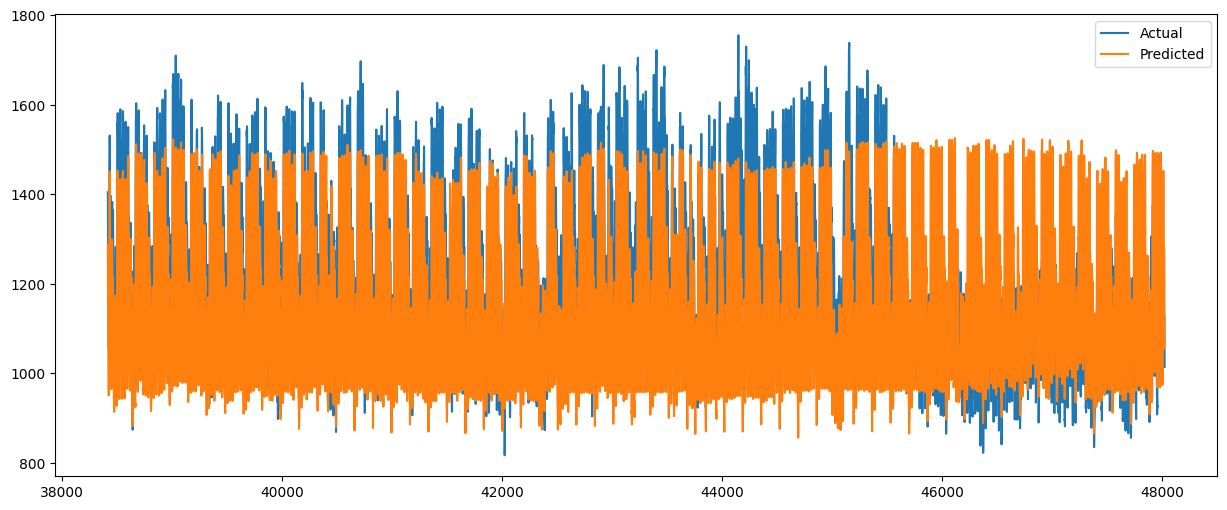

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, prediction_rf, label="Predicted")
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
X = df.drop(columns=['nat_demand'])
y = df['nat_demand']

In [ ]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

In [ ]:
model_xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
prediction_xgb = model_xgb.predict(X_test)

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, prediction_xgb))
mae = mean_absolute_error(y_test, prediction_xgb)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 29.766296668599793
MAE: 20.499419337686266


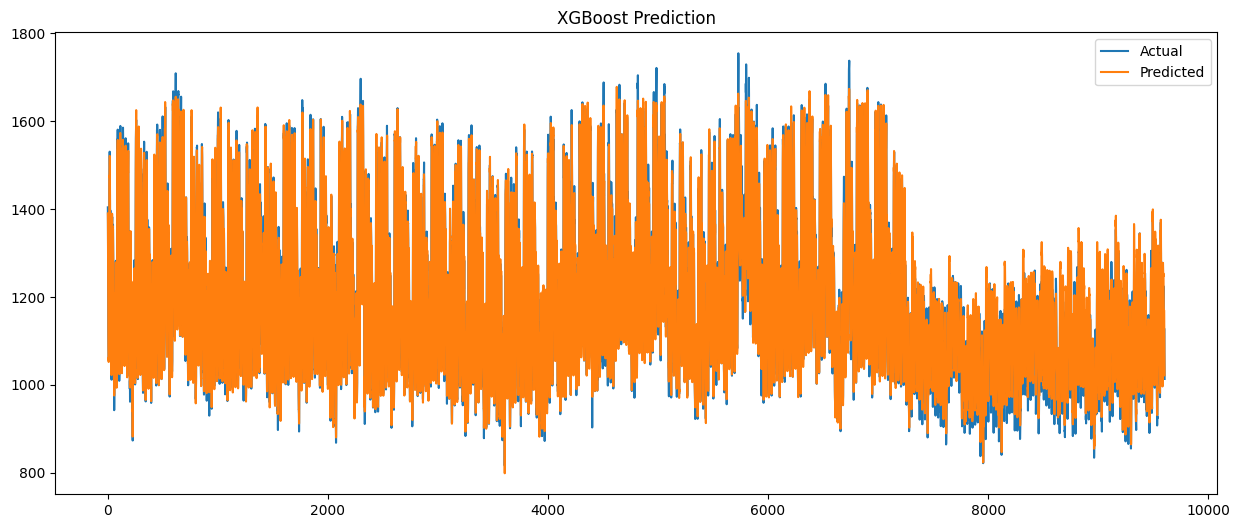

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
plt.plot(y_test.values, label='Actual')
plt.plot(prediction_xgb, label='Predicted')
plt.legend()
plt.title("XGBoost Prediction")
plt.show()

In [ ]:
!pip install lightgbm

In [ ]:
from lightgbm import LGBMRegressor

In [ ]:
model_lgbm = LGBMRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=8,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model_lgbm.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009729 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3934
[LightGBM] [Info] Number of data points in the train set: 38419, number of used features: 23
[LightGBM] [Info] Start training from score 1175.710578


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03, max_depth=8,
              n_estimators=800, random_state=42, subsample=0.8)

In [ ]:
prediction_lgbm = model_lgbm.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, prediction_lgbm))
mae = mean_absolute_error(y_test, prediction_lgbm)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 28.77434167796973
MAE: 19.809257033025


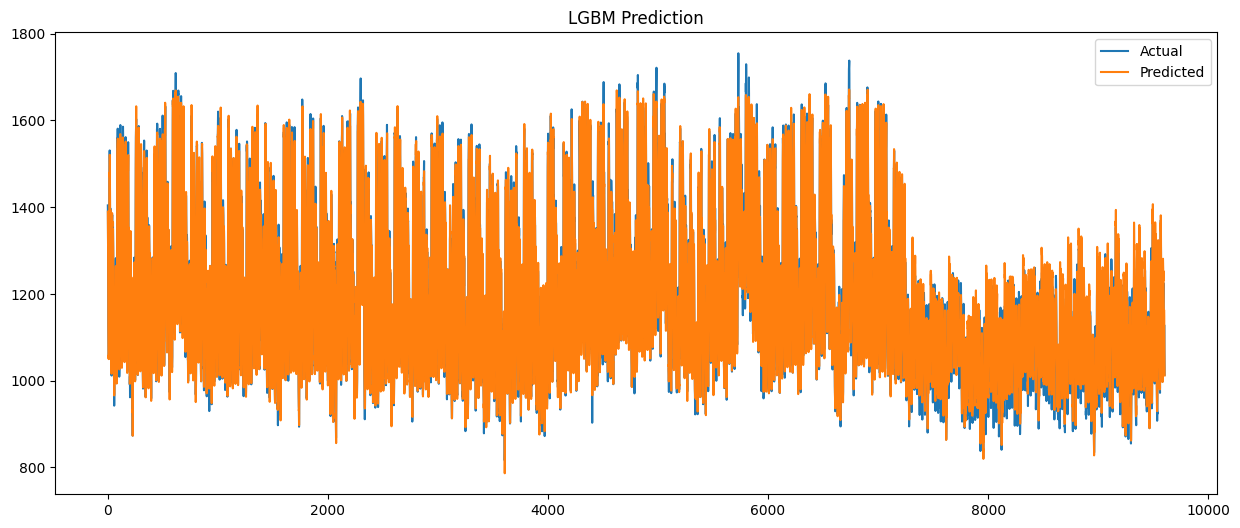

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
plt.plot(y_test.values, label='Actual')
plt.plot(prediction_lgbm, label='Predicted')
plt.legend()
plt.title("LGBM Prediction")
plt.show()

In [ ]:
!pip install catboost

In [ ]:
from catboost import CatBoostRegressor

In [ ]:
model_cat = CatBoostRegressor(
    iterations=800,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=3,
    verbose=0,
    random_state=42
)

model_cat.fit(X_train, y_train)

CatBoostRegressor(depth=8, iterations=800, l2_leaf_reg=3, learning_rate=0.03, loss_function='RMSE', random_state=42, verbose=0)

In [ ]:
prediction_cat = model_cat.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, prediction_cat))
mae = mean_absolute_error(y_test, prediction_cat)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 25.116550532769605
MAE: 17.780349894776585


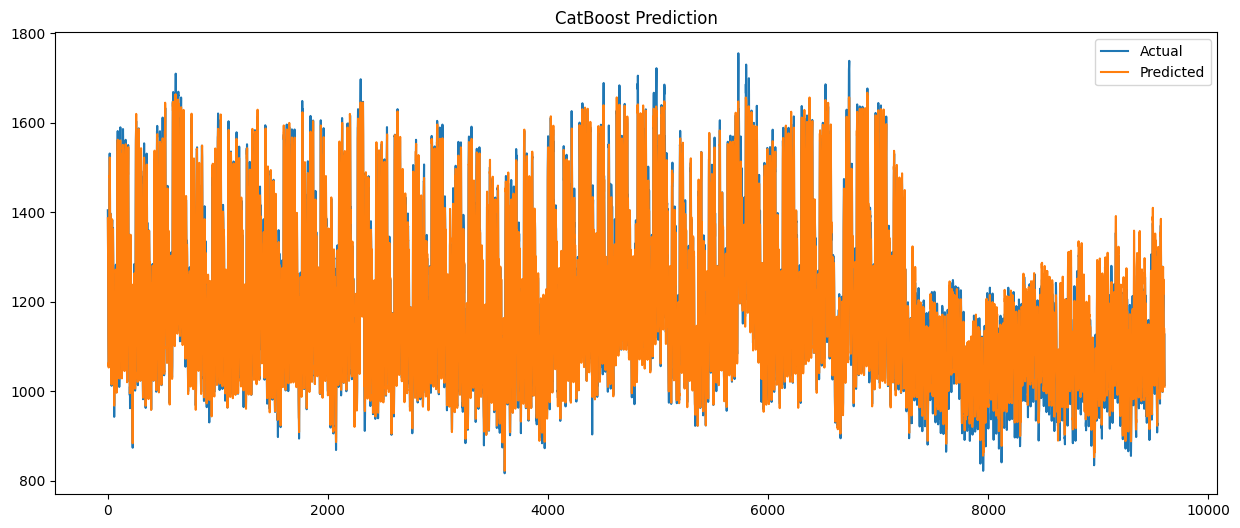

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
plt.plot(y_test.values, label='Actual')
plt.plot(prediction_cat, label='Predicted')
plt.legend()
plt.title("CatBoost Prediction")
plt.show()

In [ ]:
!pip install statsmodels

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
y = df['nat_demand']

In [ ]:
split = int(len(y) * 0.8)

train = y[:split]
test  = y[split:]

In [ ]:
model = ARIMA(train, order=(5,1,0))  # (p,d,q)
model_fit = model.fit()

In [ ]:
forecast = model_fit.forecast(steps=len(test))

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['nat_demand'])
print(result[1])  # p-value

0.0


In [ ]:
df['diff'] = df['nat_demand'].diff().dropna()

In [ ]:
print(y.describe())

count    48024.000000
mean      1182.927527
std        192.079570
min         85.192500
25%       1020.081925
50%       1168.529700
75%       1327.621200
max       1754.882000
Name: nat_demand, dtype: float64


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, forecast))
mae = mean_absolute_error(test, forecast)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 358.01460287516403
MAE: 315.8496867974396


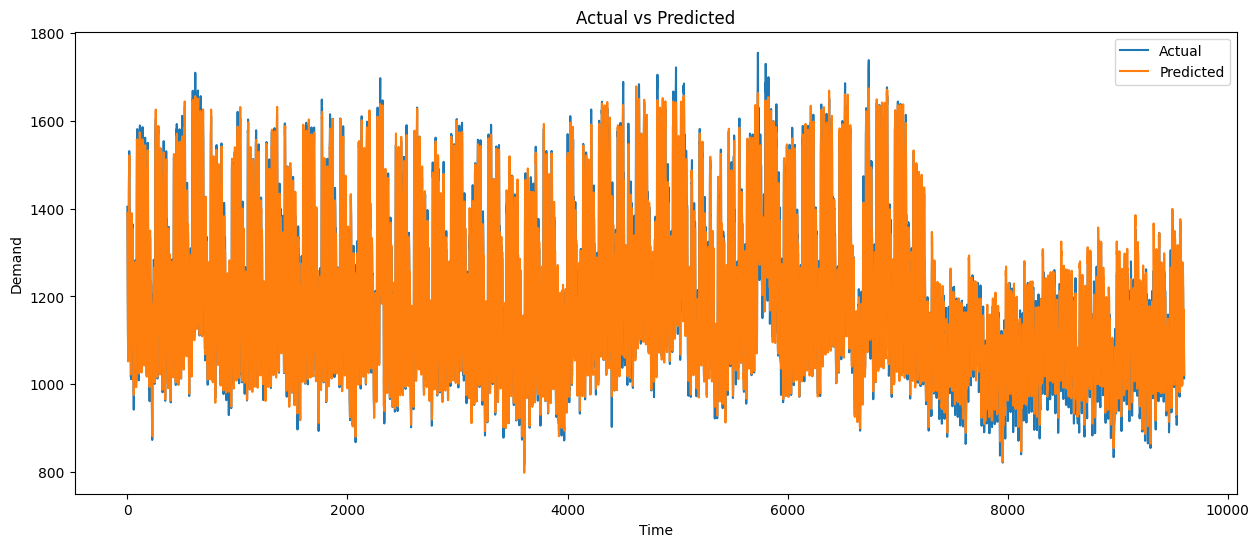

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(y_test.reset_index(drop=True), label='Actual')
plt.plot(pd.Series(prediction_xgb), label='Predicted')

plt.legend()
plt.title("Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Demand")

plt.show()

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# reshape data
X_lstm = X.values.reshape((X.shape[0], 1, X.shape[1]))

X_train_lstm = X_lstm[:split]
X_test_lstm  = X_lstm[split:]

model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(1, X.shape[1])))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.fit(X_train_lstm, y_train, epochs=10, verbose=1)

pred_lstm = model.predict(X_test_lstm)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1201/1201 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 15016.1299
Epoch 2/10
1201/1201 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 3051.7861
Epoch 3/10
1201/1201 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 2645.1602
Epoch 4/10
1201/1201 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 2545.5088
Epoch 5/10
1201/1201 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2476.4783
Epoch 6/10
1201/1201 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2464.9412
Epoch 7/10
1201/1201 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 2461.1743
Epoch 8/10
1201/1201 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2394.1143
Epoch 9/10
1201/1201 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2385.2622
Epoch 10/10
1201/1201 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2375.6626
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [ ]:
data = df['nat_demand'].values.reshape(-1,1)

In [ ]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [ ]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 24

X, y = create_sequences(data_scaled, seq_length)

In [ ]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
model = Sequential([
    LSTM(50, activation='relu', input_shape=(seq_length, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

Epoch 1/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 0.0101
Epoch 2/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.0011
Epoch 3/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 7.8965e-04
Epoch 4/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 6.7196e-04
Epoch 5/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - loss: 6.2237e-04
Epoch 6/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 5.9752e-04
Epoch 7/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5.9434e-04
Epoch 8/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 5.6697e-04
Epoch 9/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - loss: 5.5986e-04
Epoch 10/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 5.2934e-04


In [ ]:
pred = model.predict(X_test)

300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [ ]:
pred = scaler.inverse_transform(pred)
y_test_actual = scaler.inverse_transform(y_test)

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test_actual, pred))
mae = mean_absolute_error(y_test_actual, pred)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 35.678083358885765
MAE: 26.040987355733236


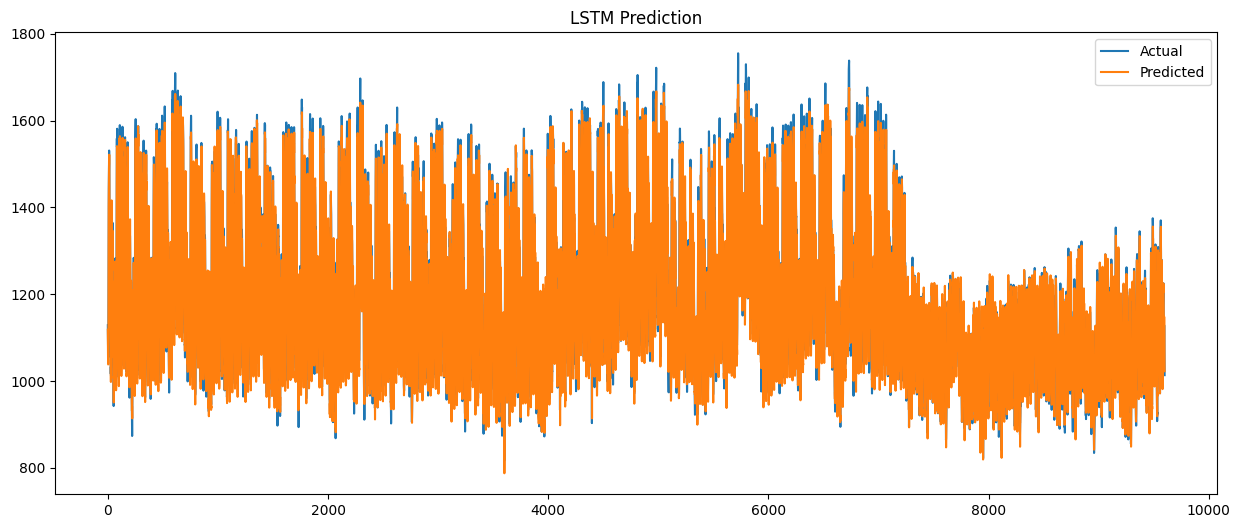

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(y_test_actual, label='Actual')
plt.plot(pred, label='Predicted')
plt.legend()
plt.title("LSTM Prediction")
plt.show()
#“LSTM captures temporal dependencies using sequential data, unlike tree-based models. However, it requires more tuning and computational power.”